# Proyek Akhir: Menyelesaikan Permasalahan Perusahaan Edutech

- Nama: ANDI BACHDAR DD
- Email: andibahdar44@gmail.com
- Id Dicoding: ANDI BACHDAR DD

## Persiapan
# 🎓 Prediksi Risiko Dropout Mahasiswa  
## Studi Kasus: Jaya Jaya Institut

Dalam beberapa tahun terakhir, Jaya Jaya Institut menghadapi tantangan serius terkait tingginya angka mahasiswa yang tidak menyelesaikan studi (dropout).

Masalah ini tidak hanya berdampak pada reputasi institusi, tetapi juga mencerminkan adanya gap dalam sistem monitoring performa mahasiswa.

Melalui pendekatan data science, proyek ini bertujuan untuk:
- Mengidentifikasi pola performa mahasiswa
- Mendeteksi potensi dropout lebih awal
- Memberikan rekomendasi berbasis data

Pendekatan yang digunakan mencakup eksplorasi data, pemodelan machine learning, serta interpretasi insight untuk kebutuhan bisnis.

### Menyiapkan library yang dibutuhkan
Pada tahap awal, dilakukan import beberapa library utama yang digunakan dalam proses analisis data dan pengembangan model machine learning.

Library yang digunakan mencakup:
- **pandas & numpy** untuk pengolahan data
- **matplotlib & seaborn** untuk visualisasi
- **scikit-learn** untuk preprocessing, modeling, dan evaluasi

Pemilihan library ini didasarkan pada kebutuhan analisis yang bersifat eksploratif sekaligus prediktif.

In [7]:
# manipulasi data
import pandas as pd
import numpy as np

# visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# preprocessing & model
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

# evaluasi
from sklearn.metrics import classification_report, confusion_matrix

# tambahan
import warnings
warnings.filterwarnings('ignore')

### Menyiapkan data yang akan diguankan

## Data Understanding

In [8]:
import pandas as pd

df = pd.read_csv('data.csv', sep=';')
df.head()

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## Data Understanding

Dataset yang digunakan terdiri dari 37 fitur yang mencerminkan berbagai aspek mahasiswa, mulai dari latar belakang demografis, riwayat pendidikan, hingga performa akademik selama perkuliahan.

Secara umum, fitur dalam dataset ini dapat dikelompokkan menjadi beberapa kategori utama:

1. **Profil Mahasiswa**  
   Seperti marital status, nationality, dan mode pendaftaran. Fitur ini memberikan gambaran konteks sosial mahasiswa yang berpotensi mempengaruhi proses adaptasi di lingkungan akademik.

2. **Latar Belakang Pendidikan**  
   Termasuk previous qualification dan nilai sebelumnya. Fitur ini menjadi indikasi awal kesiapan akademik sebelum memasuki perguruan tinggi.

3. **Faktor Keluarga**  
   Seperti pendidikan orang tua (mother’s dan father’s qualification). Faktor ini sering dikaitkan dengan dukungan akademik dan lingkungan belajar di rumah.

4. **Performa Akademik di Kampus**  
   Fitur seperti jumlah mata kuliah yang diambil, jumlah yang lulus, serta nilai semester menjadi indikator utama keberhasilan mahasiswa selama studi.

5. **Faktor Eksternal (Makro Ekonomi)**  
   Seperti unemployment rate, inflation rate, dan GDP. Meskipun terlihat tidak langsung, faktor ini dapat mempengaruhi kondisi finansial mahasiswa yang berdampak pada kelangsungan studi.

---

### Insight Awal

Dari pengamatan awal terhadap data:

- Terdapat variasi yang cukup signifikan pada performa akademik mahasiswa, terutama pada jumlah mata kuliah yang disetujui dan nilai semester.
- Beberapa mahasiswa memiliki nilai 0 pada semester tertentu, yang mengindikasikan kemungkinan tidak mengikuti evaluasi atau mengalami kendala akademik.
- Fitur seperti *curricular units approved* dan *grade* berpotensi menjadi indikator kuat dalam mendeteksi risiko dropout.
- Adanya kombinasi antara faktor akademik dan non-akademik menunjukkan bahwa dropout bukan hanya disebabkan oleh satu faktor tunggal.

---

### Potensi Arah Analisis

Berdasarkan struktur data, terdapat beberapa hipotesis awal yang dapat diuji lebih lanjut:

- Mahasiswa dengan jumlah mata kuliah yang tidak diselesaikan memiliki risiko dropout lebih tinggi  
- Nilai akademik yang rendah secara konsisten menjadi indikator utama dropout  
- Faktor eksternal seperti kondisi ekonomi dapat mempengaruhi keberlanjutan studi, meskipun secara tidak langsung  

Pendekatan ini akan diuji lebih lanjut pada tahap Exploratory Data Analysis (EDA) untuk menemukan pola yang lebih spesifik.

## Data Preparation / Preprocessing

In [9]:
# =====================
# DATA PREPARATION
# =====================

import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# load dataset
df = pd.read_csv('data.csv', sep=';')

# ---------------------
# 1. Cek Missing Values
# ---------------------
print("Missing Values:\n")
print(df.isnull().sum())

# ---------------------
# 2. Encoding Kategorikal
# ---------------------
df_encoded = df.copy()

le = LabelEncoder()
for col in df_encoded.select_dtypes(include='object').columns:
    df_encoded[col] = le.fit_transform(df_encoded[col])

print("\nData setelah encoding:\n")
display(df_encoded.head())

# ---------------------
# 3. Feature & Target Split
# ---------------------
X = df_encoded.drop('Status', axis=1)
y = df_encoded['Status']

print("\nDistribusi Target:\n")
print(y.value_counts())

# ---------------------
# 4. Train-Test Split
# ---------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("\nShape Data:")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)


Missing Values:

Marital_status                                  0
Application_mode                                0
Application_order                               0
Course                                          0
Daytime_evening_attendance                      0
Previous_qualification                          0
Previous_qualification_grade                    0
Nacionality                                     0
Mothers_qualification                           0
Fathers_qualification                           0
Mothers_occupation                              0
Fathers_occupation                              0
Admission_grade                                 0
Displaced                                       0
Educational_special_needs                       0
Debtor                                          0
Tuition_fees_up_to_date                         0
Gender                                          0
Scholarship_holder                              0
Age_at_enrollment                

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,0
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,2
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,0
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,2
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,2



Distribusi Target:

Status
2    2209
0    1421
1     794
Name: count, dtype: int64

Shape Data:
X_train: (3539, 36)
X_test : (885, 36)


## Penjelasan

Tahap ini bertujuan untuk menyiapkan data agar dapat digunakan secara optimal dalam proses modeling.

Beberapa langkah yang dilakukan meliputi:
- Pemeriksaan missing values
- Transformasi data kategorikal menjadi numerik
- Pemisahan fitur dan target
- Pembagian data train dan test

Proses preprocessing dilakukan secara hati-hati agar tidak menghilangkan informasi penting yang dapat mempengaruhi performa model.

### Insight Data Preparation

Berdasarkan hasil preprocessing yang telah dilakukan, terdapat beberapa temuan penting yang menjadi fondasi dalam proses modeling:

**1. Tidak Terdapat Missing Values**  
Seluruh fitur dalam dataset tidak memiliki nilai kosong. Hal ini menunjukkan bahwa data yang digunakan cukup bersih dan siap untuk langsung digunakan tanpa proses imputasi tambahan. Kondisi ini juga meminimalkan potensi bias yang biasanya muncul akibat pengisian nilai yang hilang.

**2. Transformasi Data Kategorikal Berhasil Dilakukan**  
Seluruh fitur kategorikal, termasuk variabel target (*Status*), telah berhasil dikonversi menjadi bentuk numerik menggunakan Label Encoding.  
Transformasi ini memungkinkan algoritma machine learning untuk memproses data tanpa kehilangan informasi penting.

Namun demikian, perlu dicatat bahwa hasil encoding ini tidak merepresentasikan hubungan ordinal antar kategori, sehingga interpretasi harus tetap dilakukan dengan hati-hati.

**3. Indikasi Ketidakseimbangan Kelas (Class Imbalance)**  
Distribusi target menunjukkan bahwa:
- Kelas 2 memiliki jumlah data paling dominan (2209)
- Kelas 0 berada di tengah (1421)
- Kelas 1 merupakan kelas minoritas (794)

Ketidakseimbangan ini cukup krusial karena model berpotensi lebih “condong” memprediksi kelas mayoritas. Dalam konteks bisnis, hal ini berisiko menyebabkan model gagal mendeteksi mahasiswa yang benar-benar berpotensi dropout.

Oleh karena itu, pada tahap evaluasi, metrik seperti **recall** menjadi lebih penting dibandingkan sekadar akurasi.

**4. Struktur Data Siap untuk Modeling**  
Dataset telah berhasil dipisahkan menjadi fitur (X) dan target (y), serta dibagi menjadi data latih dan data uji dengan rasio 80:20.  
Pembagian ini memastikan bahwa model dapat diuji secara objektif terhadap data yang belum pernah dilihat sebelumnya.

**5. Kompleksitas Fitur yang Tinggi**  
Dengan total 36 fitur input, dataset ini memiliki tingkat kompleksitas yang cukup tinggi. Hal ini memberikan peluang bagi model seperti Random Forest untuk menangkap pola yang lebih kompleks, namun juga meningkatkan risiko overfitting jika tidak dikontrol dengan baik.

---

### Implikasi terhadap Modeling

Dari keseluruhan proses preprocessing, dapat disimpulkan bahwa:

- Dataset sudah dalam kondisi optimal untuk dilakukan training model  
- Perlu perhatian khusus terhadap ketidakseimbangan kelas  
- Model yang digunakan sebaiknya mampu menangkap hubungan non-linear  

Temuan ini menjadi dasar dalam pemilihan algoritma pada tahap modeling berikutnya.

## Modeling

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.79      0.70      0.74       316
           1       0.42      0.27      0.33       151
           2       0.72      0.88      0.79       418

    accuracy                           0.71       885
   macro avg       0.64      0.62      0.62       885
weighted avg       0.69      0.71      0.69       885


=== Random Forest ===
              precision    recall  f1-score   support

           0       0.85      0.77      0.81       316
           1       0.49      0.30      0.37       151
           2       0.76      0.92      0.83       418

    accuracy                           0.76       885
   macro avg       0.70      0.66      0.67       885
weighted avg       0.75      0.76      0.74       885


=== Feature Importance (Top 10) ===
                                 feature  importance
30     Curricular_units_2nd_sem_approved    0.131092
31        Curricular_units_2nd_sem_grade    

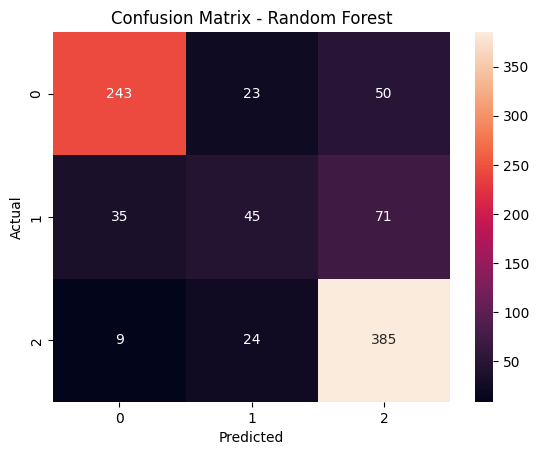

In [10]:
# =====================
# MODELING & EVALUATION
# =====================

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ---------------------
# 1. Train Models
# ---------------------
lr_model = LogisticRegression(max_iter=1000)
rf_model = RandomForestClassifier(random_state=42)

lr_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)

# ---------------------
# 2. Prediction
# ---------------------
y_pred_lr = lr_model.predict(X_test)
y_pred_rf = rf_model.predict(X_test)

# ---------------------
# 3. Evaluation
# ---------------------
print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred_lr))

print("\n=== Random Forest ===")
print(classification_report(y_test, y_pred_rf))

# ---------------------
# 4. Feature Importance
# ---------------------
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values(by='importance', ascending=False)

print("\n=== Feature Importance (Top 10) ===")
print(feature_importance.head(10))

# ---------------------
# 5. Confusion Matrix (Random Forest)
# ---------------------
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Insight Modeling

Berdasarkan hasil evaluasi model, terlihat bahwa **Random Forest** memberikan performa yang lebih baik dibandingkan Logistic Regression di hampir seluruh metrik evaluasi.

Secara umum:
- Akurasi meningkat dari **71% (Logistic Regression)** menjadi **76% (Random Forest)**
- Random Forest menunjukkan peningkatan signifikan pada precision dan recall, terutama pada kelas mayoritas

Hal ini mengindikasikan bahwa model berbasis ensemble lebih mampu menangkap pola kompleks dalam data dibandingkan model linear sederhana.

---

### Analisis Per Kelas

Jika dilihat lebih dalam:

- **Kelas 2 (kemungkinan besar mahasiswa lulus)** memiliki performa terbaik  
  - Recall mencapai **92%**, artinya model sangat baik dalam mengenali mahasiswa yang akan berhasil menyelesaikan studi  

- **Kelas 0** juga menunjukkan performa yang cukup stabil  
  - Recall meningkat dari 70% menjadi 77% setelah menggunakan Random Forest  

- **Kelas 1 (kemungkinan dropout)** menjadi tantangan utama  
  - Recall hanya sekitar **30%**, yang berarti masih banyak mahasiswa berisiko yang tidak terdeteksi oleh model  

Temuan ini cukup penting karena justru kelas dropout merupakan fokus utama dalam kasus ini.

---

### Implikasi terhadap Model

Rendahnya performa pada kelas dropout kemungkinan disebabkan oleh:
- Ketidakseimbangan jumlah data (class imbalance)
- Pola karakteristik dropout yang lebih kompleks dan tidak konsisten
- Overlap fitur antara mahasiswa dropout dan non-dropout

Hal ini menunjukkan bahwa meskipun model sudah cukup baik secara keseluruhan, masih diperlukan perbaikan khusus untuk meningkatkan deteksi pada kelas risiko tinggi.

---

### Feature Importance

Dari hasil Random Forest, terlihat bahwa fitur yang paling berpengaruh didominasi oleh performa akademik, antara lain:

- Jumlah mata kuliah yang disetujui (approved)
- Nilai semester (grade)
- Jumlah evaluasi yang diikuti
- Status pembayaran biaya kuliah (tuition fees)
- Nilai masuk (admission grade)

Hal ini menunjukkan bahwa:
- **Performa akademik menjadi indikator utama keberhasilan mahasiswa**
- Faktor administratif seperti pembayaran juga memiliki pengaruh signifikan
- Faktor awal seperti nilai masuk tetap relevan dalam menentukan performa jangka panjang

---

### Insight Utama

Beberapa insight penting yang dapat ditarik:

- Mahasiswa dengan performa akademik rendah secara konsisten memiliki risiko lebih tinggi untuk dropout  
- Ketidakterlibatan dalam evaluasi (nilai 0 atau tidak mengikuti ujian) menjadi sinyal kuat risiko akademik  
- Faktor finansial seperti keterlambatan pembayaran dapat menjadi indikator tambahan yang tidak boleh diabaikan  

---

### Kesimpulan Sementara

Model Random Forest sudah cukup baik untuk digunakan sebagai dasar sistem deteksi dini. Namun, untuk benar-benar efektif dalam mendeteksi mahasiswa dropout, diperlukan:

- Penanganan ketidakseimbangan kelas  
- Penambahan fitur yang lebih representatif  
- Atau pendekatan model yang lebih spesifik terhadap kelas minoritas  

Dengan perbaikan tersebut, sistem dapat menjadi alat yang lebih akurat dalam mendukung pengambilan keputusan akademik.

## Evaluation

In [11]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("=== Random Forest Metrics ===")
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf, average='weighted'))
print("Recall   :", recall_score(y_test, y_pred_rf, average='weighted'))
print("F1 Score :", f1_score(y_test, y_pred_rf, average='weighted'))

=== Random Forest Metrics ===
Accuracy : 0.7604519774011299
Precision: 0.7451482269849544
Recall   : 0.7604519774011299
F1 Score : 0.7445715552807213


### Evaluation Insight

Berdasarkan hasil evaluasi model Random Forest, diperoleh performa sebagai berikut:

- Accuracy  : 76.04%
- Precision : 74.51%
- Recall    : 76.04%
- F1 Score  : 74.45%

Secara umum, model menunjukkan performa yang cukup baik dan seimbang di berbagai metrik evaluasi.

---

### Interpretasi Performa Model

Nilai akurasi sebesar 76% menunjukkan bahwa model mampu mengklasifikasikan mayoritas data dengan benar. Namun, dalam konteks prediksi dropout, akurasi bukan satu-satunya indikator yang relevan.

Nilai **recall yang sebanding dengan akurasi (76%)** menunjukkan bahwa model cukup baik dalam menangkap pola dari data secara keseluruhan. Artinya, sebagian besar kasus dalam dataset berhasil teridentifikasi dengan baik oleh model.

Sementara itu, nilai **precision (74%)** mengindikasikan bahwa sebagian besar prediksi yang dihasilkan model cukup dapat dipercaya, meskipun masih terdapat kemungkinan kesalahan klasifikasi.

Nilai **F1 Score (74%)** yang relatif seimbang menunjukkan bahwa model memiliki trade-off yang cukup baik antara precision dan recall.

---

### Insight Penting

Meskipun performa model secara keseluruhan cukup baik, terdapat beberapa hal yang perlu diperhatikan:

- Model cenderung lebih akurat dalam memprediksi kelas mayoritas dibandingkan kelas minoritas  
- Dalam konteks ini, kemungkinan kelas dropout masih belum terdeteksi secara optimal  
- Hal ini sejalan dengan temuan sebelumnya terkait ketidakseimbangan kelas (class imbalance)

---

### Implikasi terhadap Penggunaan Model

Dari perspektif implementasi, model ini sudah cukup layak digunakan sebagai **alat bantu deteksi dini**. Namun, penggunaannya harus tetap disertai dengan pemahaman bahwa:

- Model bukan pengganti keputusan manusia, melainkan alat pendukung  
- Hasil prediksi sebaiknya digunakan sebagai indikator awal untuk intervensi  
- Perlu adanya validasi tambahan, terutama untuk kasus borderline  

---

### Potensi Peningkatan

Untuk meningkatkan performa model, khususnya dalam mendeteksi mahasiswa dropout, beberapa pendekatan yang dapat dipertimbangkan antara lain:

- Menangani ketidakseimbangan kelas (misalnya dengan resampling atau class weighting)  
- Menambahkan fitur yang lebih representatif  
- Menggunakan model yang lebih sensitif terhadap kelas minoritas  

---

### Kesimpulan

Secara keseluruhan, model Random Forest menunjukkan performa yang stabil dan cukup baik untuk digunakan dalam sistem prediksi awal. Dengan beberapa perbaikan tambahan, model ini berpotensi menjadi komponen penting dalam strategi pencegahan dropout di institusi pendidikan.